In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd

In [2]:
# Загрузка графа 
GG = ox.graph_from_place('Красноярск, Красноярский край, Россия', network_type='drive')
for u, v, d in GG.edges(data=True):
    if 'osmid' not in d:
        d['osmid'] = None
        

In [3]:
# Кол-во узлов и ребер
GG.number_of_nodes(), GG.number_of_edges()

(4477, 10799)

In [4]:
# Координаты узлов
list(GG.nodes(data=True))[:10]

[(182689941,
  {'y': 56.065227,
   'x': 92.9550346,
   'highway': 'traffic_signals',
   'street_count': 4}),
 (276573703, {'y': 56.0742638, 'x': 92.9407368, 'street_count': 3}),
 (276573768, {'y': 56.0714047, 'x': 92.9391596, 'street_count': 3}),
 (276573776, {'y': 56.0737753, 'x': 92.9406566, 'street_count': 3}),
 (276573946, {'y': 56.0747365, 'x': 92.9388175, 'street_count': 3}),
 (276578101, {'y': 56.0627124, 'x': 93.0220211, 'street_count': 3}),
 (276578118, {'y': 56.0626198, 'x': 93.0235298, 'street_count': 3}),
 (276578296, {'y': 56.063784, 'x': 93.0230668, 'street_count': 3}),
 (276612219, {'y': 56.0612271, 'x': 93.0230893, 'street_count': 3}),
 (276612572, {'y': 56.0604079, 'x': 93.0250553, 'street_count': 3})]

!! Координаты используем в EPSG 4326

In [5]:
# Получение id узлов, ближайших к координатам
coord1 = (56.0698944,92.9888370)
coord2 = (56.062695,93.022040)
# В Qgis координаты записаны y,x - меняем местами
start = ox.distance.nearest_nodes(GG, coord1[1], coord1[0], return_dist=False)
finish = ox.distance.nearest_nodes(GG, coord2[1], coord2[0], return_dist=False)
# Расчет маршрута
route = ox.routing.shortest_path(GG, start, finish,weight='length')
gdf = ox.routing.route_to_gdf(GG, route, weight='length')
route_length = gdf['length'].sum()
print(f"Длина маршрута составляет {len(route)} узлов и {route_length /1000} км")

Длина маршрута составляет 2 узлов и 2.224418 км


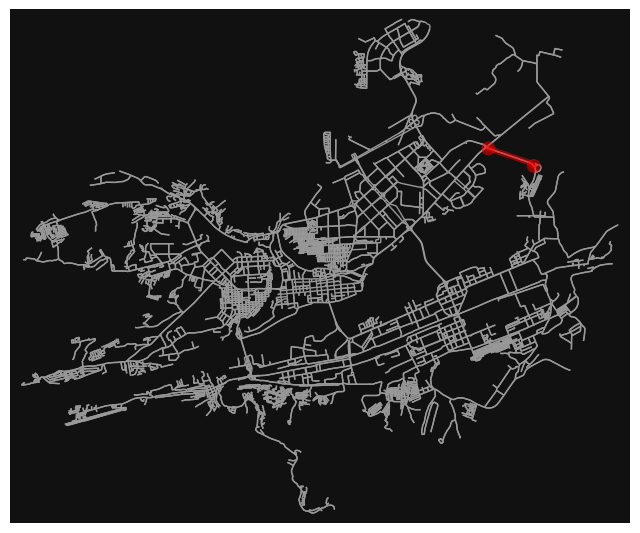

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
# Маршрут на графе
ox.plot_graph_route(GG, route, node_size=0)